# Evaluating LFADS single-session outputs

This notebook loads the HDF5 output produced by `run_single.py` and walks through
five evaluations:

1. **Example trial rasters** — raw spikes vs. LFADS inferred rates
2. **PSTH comparison** — condition-averaged rates vs. ground-truth
3. **Velocity decoding** — linear R² from factors vs. raw spikes
4. **Factor state-space** — PCA trajectories coloured by condition
5. **IC posterior distribution** — 2D PCA scatter of initial condition means

In [1]:
from glob import glob
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Load the output file

By default the cell below auto-detects the most recent `lfads_output*.h5` under `runs/`.
Override `H5_PATH` to point at a specific file.

In [2]:
# Set to None to auto-detect, or provide an explicit path string.
H5_PATH = None

if H5_PATH is None:
    candidates = sorted(glob("../runs/**/**/lfads_output*.h5", recursive=True))
    assert candidates, "No lfads_output*.h5 found. Run run_single.py first."
    H5_PATH = candidates[-1]

H5_PATH = Path(H5_PATH)
print(f"Loading: {H5_PATH}")

with h5py.File(H5_PATH) as f:
    d = {k: f[k][()] for k in f}

# Derived constants
N_OBS = d["valid_encod_data"].shape[1]   # encoder window length (e.g. 35)
print(f"  encod_seq_len = {N_OBS}")
print(f"  recon_seq_len = {d['valid_output_params'].shape[1]}")
print(f"  n_neurons     = {d['valid_output_params'].shape[2]}")
print(f"  n_factors     = {d['valid_factors'].shape[2]}")
print(f"  n_conditions  = {len(d['valid_cond_idx'])}")
print(f"  train trials  = {len(d['train_factors'])}")
print(f"  valid trials  = {len(d['valid_factors'])}")

Loading: ../runs/lfads-torch-example/nlb_mc_maze/260520_exampleSingle/lfads_output_mc_maze-20ms-val.h5
  encod_seq_len = 35
  recon_seq_len = 45
  n_neurons     = 182
  n_factors     = 100
  n_conditions  = 108
  train trials  = 1721
  valid trials  = 574


In [3]:
def cond_labels(cond_idx, n_trials):
    """Convert ragged cond_idx (one array of trial indices per condition)
    to a flat per-trial integer label array (-1 = unlabelled)."""
    labels = np.full(n_trials, -1, dtype=int)
    for c, idxs in enumerate(cond_idx):
        labels[idxs] = c
    return labels

## Fig 1 — Input spikes vs. LFADS inferred rates

Each row is one validation trial. Left: raw binned spike counts fed to the encoder.
Right: the posterior-averaged firing rates predicted by LFADS, trimmed to the same
encoder time window (`output_params[:, :N_OBS, :]`).

**What to look for:** rates should be a smooth, denoised version of the spikes —
sharp edges and isolated noisy bins should give way to smooth bumps. If the rates
look identical to the spikes the model is under-regularised; if they are completely
flat it is over-regularised.

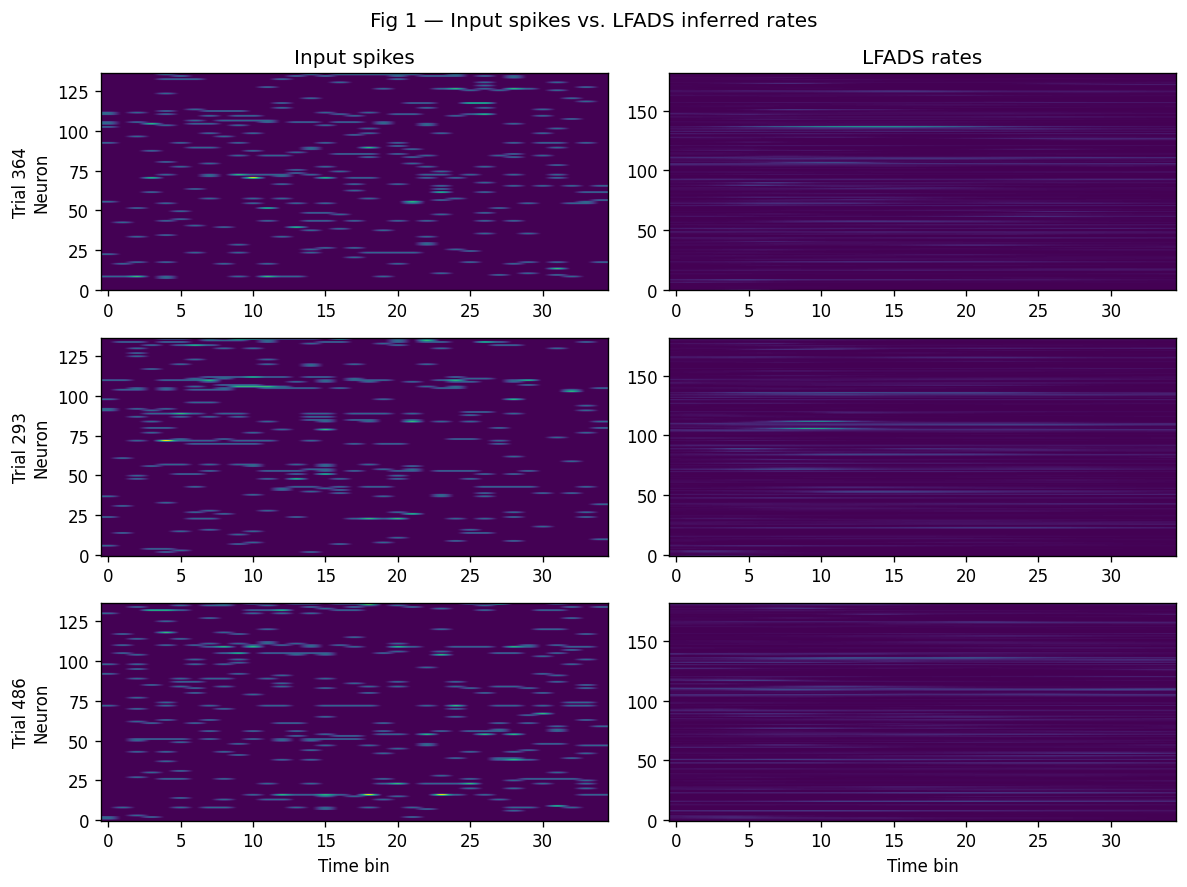

In [4]:
N_EXAMPLE_TRIALS = 3
rng = np.random.default_rng(0)

encod     = d["valid_encod_data"].astype(float)          # (N, T_enc, C_enc)
rates_obs = d["valid_output_params"][:, :N_OBS, :].astype(float)  # (N, T_enc, C_all)

idx  = rng.choice(len(encod), size=N_EXAMPLE_TRIALS, replace=False)
vmax = max(encod[idx].max(), rates_obs[idx].max())

fig, axes = plt.subplots(N_EXAMPLE_TRIALS, 2, figsize=(10, 2.5 * N_EXAMPLE_TRIALS))
for row, i in enumerate(idx):
    for col, (arr, title) in enumerate(
        [(encod[i], "Input spikes"), (rates_obs[i], "LFADS rates")]
    ):
        ax = axes[row, col]
        ax.imshow(arr.T, aspect="auto", vmin=0, vmax=vmax, origin="lower")
        if row == 0:
            ax.set_title(title)
        ax.set_ylabel(f"Trial {i}\nNeuron" if col == 0 else "")
for ax in axes[-1]:
    ax.set_xlabel("Time bin")
fig.suptitle("Fig 1 — Input spikes vs. LFADS inferred rates", fontsize=12)
plt.tight_layout()

## Fig 2 — PSTH comparison

The ground-truth PSTH (stored in the HDF5 as `psth`) is the empirical condition-averaged
firing rate computed from smoothed spikes.  The predicted PSTH is obtained by averaging
`output_params[:, :N_OBS, :]` over all validation trials belonging to each condition
(using `valid_cond_idx`).

**What to look for:** blue (GT) and red (LFADS) curves should overlap. PSTH R² near 1
means the model captured trial-averaged dynamics accurately. Large discrepancies on
specific neurons may hint at poor readin/readout alignment.

PSTH R² = 0.9194


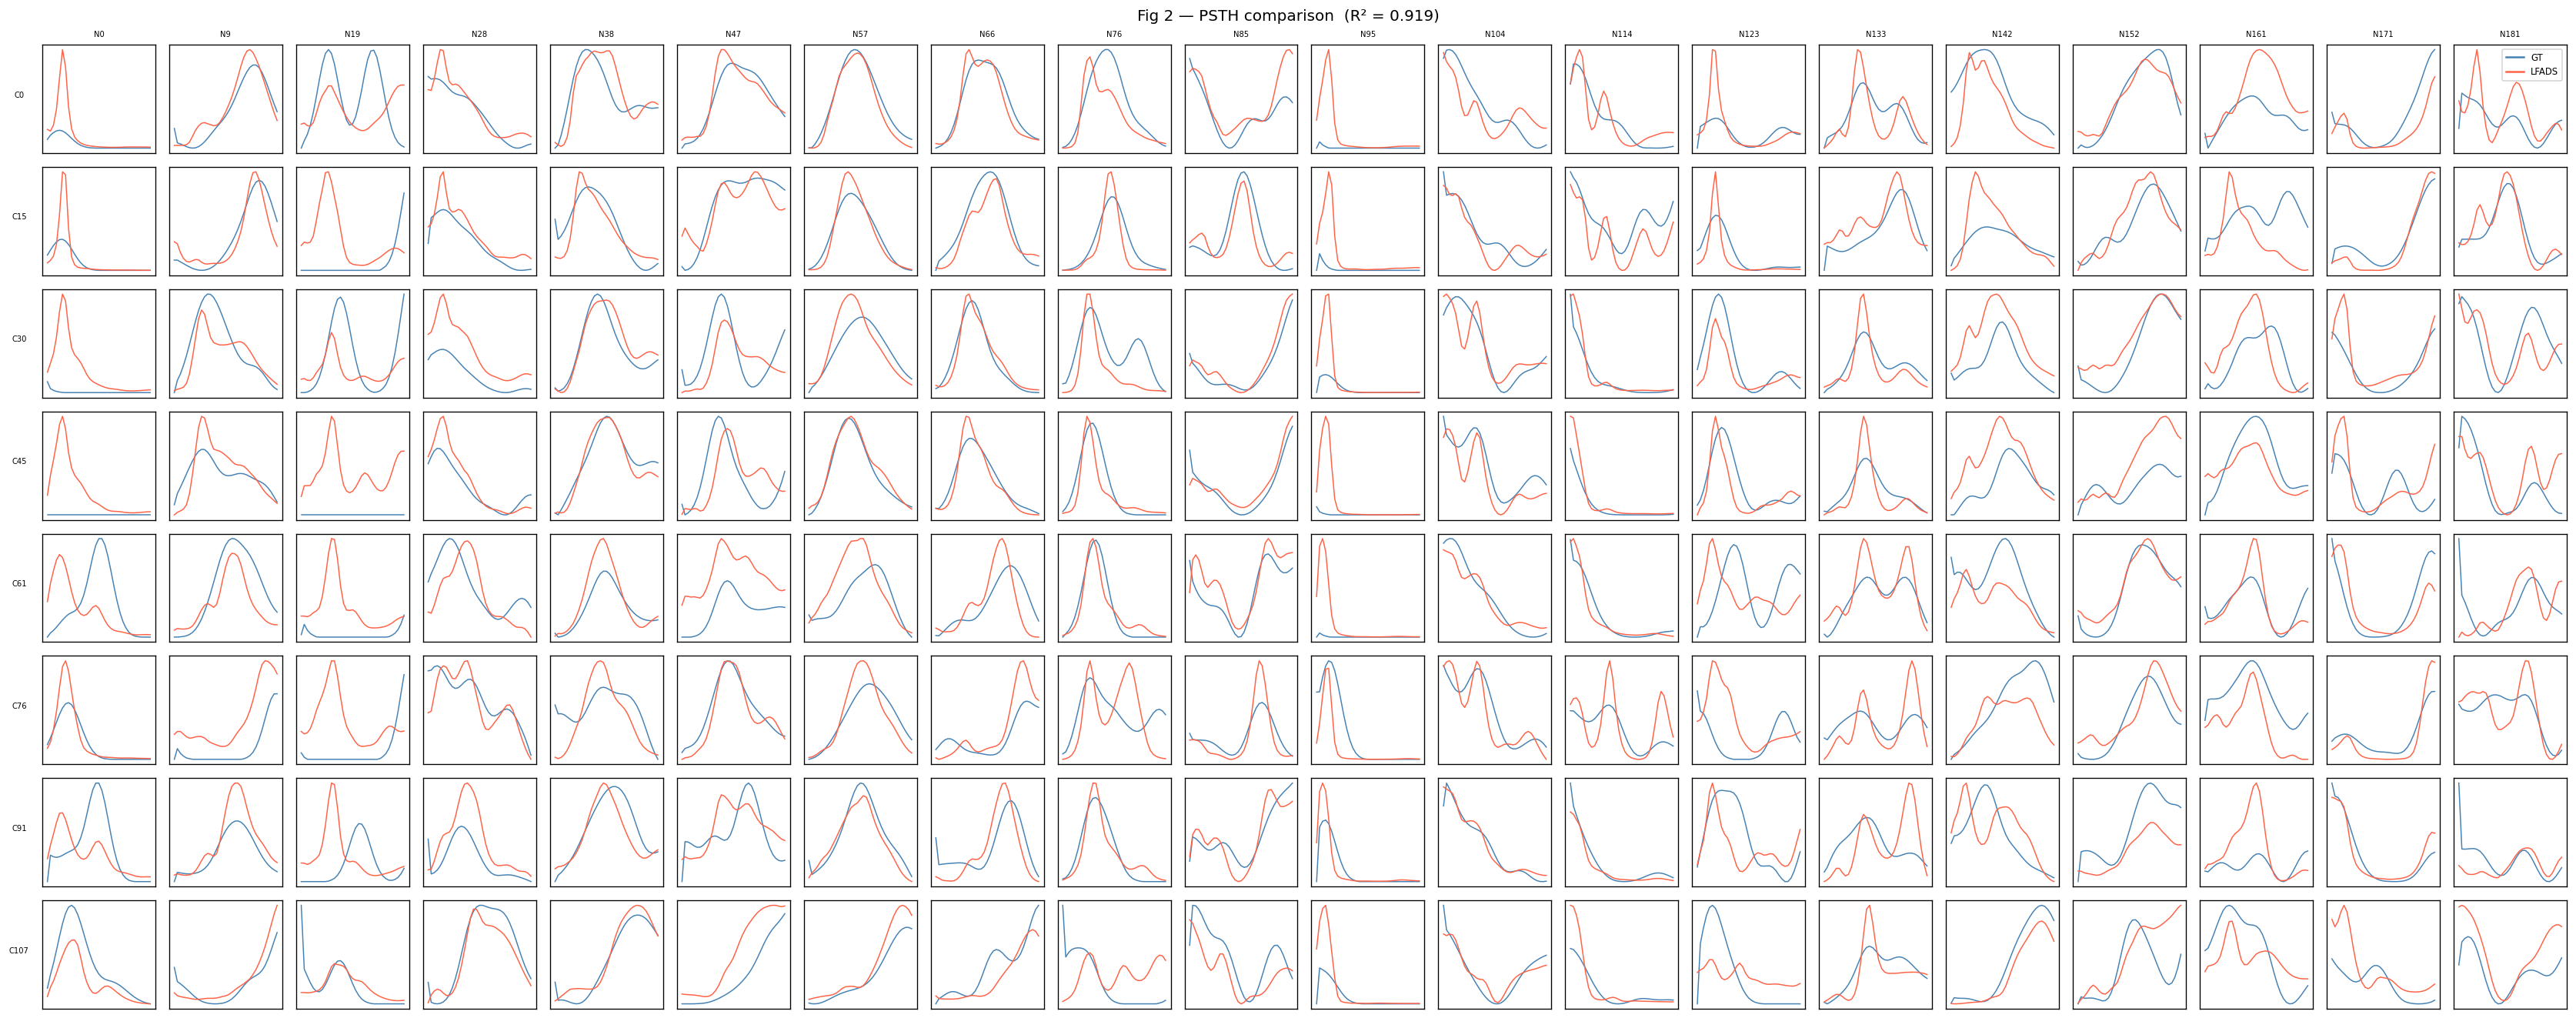

In [5]:
N_PSTH_NEURONS = 20
N_PSTH_CONDS   = 8

psth_gt   = d["psth"].astype(float)          # (C, T_enc, N_all)
cond_idx  = d["valid_cond_idx"]
n_conds   = len(cond_idx)

# Predicted PSTH: average rates over valid trials per condition
pred_psth = np.full_like(psth_gt, np.nan)
for c, idxs in enumerate(cond_idx):
    if len(idxs) > 0:
        pred_psth[c] = rates_obs[idxs].mean(axis=0)

# PSTH R²
mask   = ~np.isnan(pred_psth).any(axis=(1, 2))
g, p   = psth_gt[mask].ravel(), pred_psth[mask].ravel()
psth_r2 = 1.0 - np.sum((g - p) ** 2) / np.sum((g - g.mean()) ** 2)
print(f"PSTH R² = {psth_r2:.4f}")

sel_conds   = np.linspace(0, n_conds - 1, N_PSTH_CONDS, dtype=int)
sel_neurons = np.linspace(0, psth_gt.shape[2] - 1, N_PSTH_NEURONS, dtype=int)
t = np.arange(N_OBS)

fig, axes = plt.subplots(
    N_PSTH_CONDS, N_PSTH_NEURONS,
    figsize=(N_PSTH_NEURONS * 1.4, N_PSTH_CONDS * 1.4),
    squeeze=False,
)
for ri, c in enumerate(sel_conds):
    for ci, n in enumerate(sel_neurons):
        ax = axes[ri, ci]
        ax.plot(t, psth_gt[c, :, n],   color="steelblue", lw=0.9)
        ax.plot(t, pred_psth[c, :, n], color="tomato",    lw=0.9)
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title(f"N{n}", fontsize=6)
    axes[ri, 0].set_ylabel(f"C{c}", fontsize=6, rotation=0, labelpad=18)

# Manual legend
from matplotlib.lines import Line2D
axes[0, -1].legend(
    handles=[
        Line2D([0], [0], color="steelblue", lw=1.5, label="GT"),
        Line2D([0], [0], color="tomato",    lw=1.5, label="LFADS"),
    ],
    fontsize=7, loc="upper right", framealpha=0.8,
)
fig.suptitle(f"Fig 2 — PSTH comparison  (R² = {psth_r2:.3f})", fontsize=12)
plt.tight_layout()

## Fig 3 — Velocity decoding

A Ridge regression decoder is trained on the **training set** and evaluated on the
**validation set** to predict 2D hand velocity.  Two feature sets are compared:

- **LFADS factors** `factors[:, :N_OBS, :]` — the compressed latent representation
- **Raw spikes** `encod_data` — the unprocessed input to the model

Only trials flagged by `decode_mask` are used (NLB convention).
R² is reported separately for x- and y-velocity.

**What to look for:** factors R² >> raw spikes R² confirms that LFADS denoising
amplified the movement-relevant signal. Similar values may indicate the regularisation
is too strong (factors have collapsed) or too weak (no denoising).

Factors R²  — x: 0.893, y: 0.841, mean: 0.867
Spikes  R²  — x: 0.260, y: 0.208, mean: 0.234


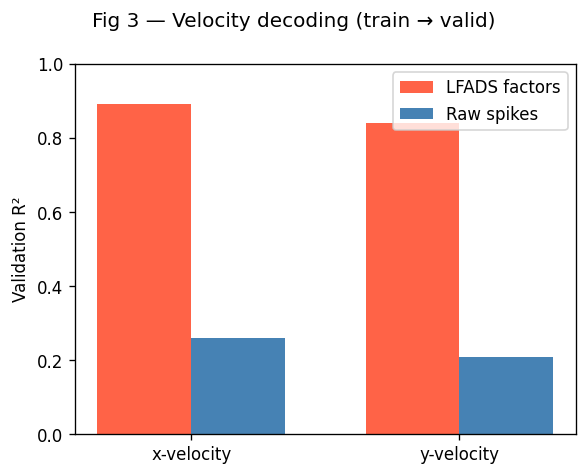

In [6]:
def decode_velocity(x_tr, y_tr, x_va, y_va):
    """Ridge regression with 5-fold group CV (groups = trials); returns R² per axis."""
    n_trials, n_time, n_feat = x_tr.shape
    groups = np.repeat(np.arange(n_trials), n_time)
    x_tr_f = x_tr.reshape(-1, n_feat)
    y_tr_f = y_tr.reshape(-1, y_tr.shape[-1])
    x_va_f = x_va.reshape(-1, n_feat)
    y_va_f = y_va.reshape(-1, y_va.shape[-1])
    model = GridSearchCV(
        Ridge(),
        param_grid={"alpha": np.logspace(-1, 2, 4)},
        cv=GroupKFold(n_splits=5),
    )
    model.fit(x_tr_f, y_tr_f, groups=groups)
    y_pred = model.predict(x_va_f)
    ss_res = np.sum((y_va_f - y_pred) ** 2, axis=0)
    ss_tot = np.sum((y_va_f - y_va_f.mean(axis=0)) ** 2, axis=0)
    return 1.0 - ss_res / ss_tot

tr_mask = d["train_decode_mask"].squeeze().astype(bool)
va_mask = d["valid_decode_mask"].squeeze().astype(bool)

tr_fac = d["train_factors"][tr_mask, :N_OBS, :].astype(float)
va_fac = d["valid_factors"][va_mask, :N_OBS, :].astype(float)
tr_spk = d["train_encod_data"][tr_mask].astype(float)
va_spk = d["valid_encod_data"][va_mask].astype(float)
tr_beh = d["train_behavior"][tr_mask, :N_OBS, :].astype(float)
va_beh = d["valid_behavior"][va_mask, :N_OBS, :].astype(float)

r2_fac = decode_velocity(tr_fac, tr_beh, va_fac, va_beh)
r2_spk = decode_velocity(tr_spk, tr_beh, va_spk, va_beh)

print(f"Factors R²  — x: {r2_fac[0]:.3f}, y: {r2_fac[1]:.3f}, mean: {r2_fac.mean():.3f}")
print(f"Spikes  R²  — x: {r2_spk[0]:.3f}, y: {r2_spk[1]:.3f}, mean: {r2_spk.mean():.3f}")

x = np.arange(2)
w = 0.35
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - w/2, r2_fac, w, label="LFADS factors", color="tomato")
ax.bar(x + w/2, r2_spk, w, label="Raw spikes",    color="steelblue")
ax.set_xticks(x); ax.set_xticklabels(["x-velocity", "y-velocity"])
ax.set_ylabel("Validation R²"); ax.set_ylim(0, 1)
ax.axhline(0, color="k", lw=0.5)
ax.legend()
fig.suptitle("Fig 3 — Velocity decoding (train → valid)", fontsize=12)
plt.tight_layout()

## Fig 4 — Factor state-space trajectories

PCA (3 components) is fit on all training + validation factors, then used to project
validation trial trajectories to 3D.  For each of 8 evenly-spaced conditions we show
individual trial trajectories (faint) and the condition mean (bold).

**What to look for:** well-trained LFADS models show smooth, condition-separated
"rotational" orbits — different reach directions trace distinct but similarly-shaped
paths through factor space.  Tangled or collapsed trajectories suggest the model
has not learned structured dynamics.

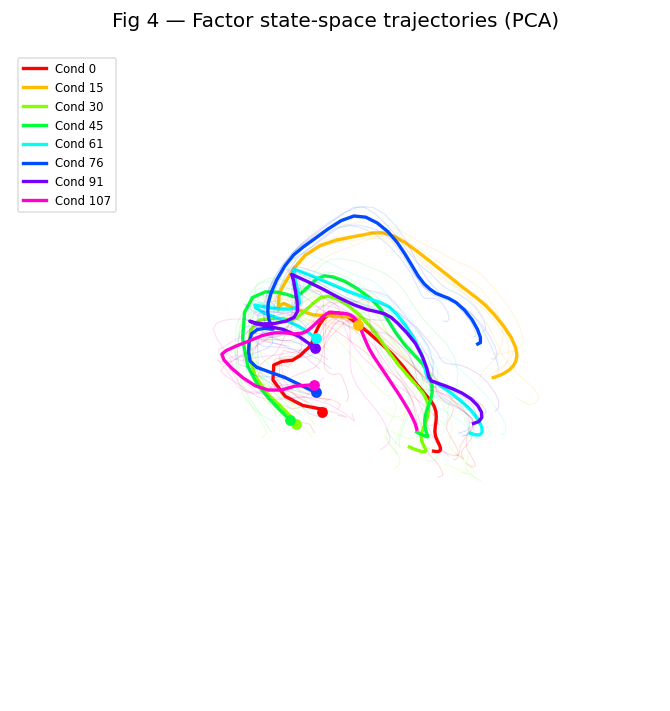

In [7]:
N_SS_CONDS      = 8
N_SS_INDIVIDUAL = 20   # individual trial traces per condition

fac_tr  = d["train_factors"].astype(float)
fac_va  = d["valid_factors"].astype(float)
fac_all = np.concatenate([fac_tr, fac_va], axis=0)

ss  = StandardScaler()
pca = PCA(n_components=3)
pca.fit(ss.fit_transform(fac_all.reshape(-1, fac_all.shape[-1])))
var_exp = pca.explained_variance_ratio_ * 100

labels_va   = cond_labels(d["valid_cond_idx"], len(fac_va))
unique_conds = np.array([c for c in np.unique(labels_va) if c >= 0])
sel_conds   = unique_conds[np.linspace(0, len(unique_conds) - 1, N_SS_CONDS, dtype=int)]

fac_va_lowd = pca.transform(ss.transform(fac_va.reshape(-1, fac_va.shape[-1])))
fac_va_lowd = fac_va_lowd.reshape(len(fac_va), -1, 3)

rng = np.random.default_rng(0)
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection="3d")

for ci, c in enumerate(sel_conds):
    color     = cm.hsv(ci / N_SS_CONDS)
    trial_idx = np.where(labels_va == c)[0]
    sample    = rng.choice(trial_idx, size=min(N_SS_INDIVIDUAL, len(trial_idx)), replace=False)
    for t in sample:
        ax.plot(*fac_va_lowd[t].T, color=color, alpha=0.15, lw=0.6)
    mean_traj = fac_va_lowd[trial_idx].mean(axis=0)
    ax.plot(*mean_traj.T, color=color, lw=2.0, label=f"Cond {c}")
    ax.scatter(*mean_traj[0], color=color, s=30, zorder=5)

ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=8)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=8)
ax.set_zlabel(f"PC3 ({var_exp[2]:.1f}%)", fontsize=8)
ax.legend(fontsize=7, loc="upper left", framealpha=0.6)
ax.view_init(elev=20, azim=40)
ax.axis("off")
fig.suptitle("Fig 4 — Factor state-space trajectories (PCA)", fontsize=12)
plt.tight_layout()

## Fig 5 — Initial condition (IC) posterior distribution

LFADS encodes each trial's starting state into a low-dimensional initial condition (IC)
via the encoder.  We run PCA (2 components) on the IC posterior means from all trials
(train + valid) and plot them as a scatter, coloured by condition.

**What to look for:** clear clustering by condition means the encoder distinguishes
trial types from their initial neural dynamics.  A blurry, condition-independent
scatter may indicate `ic_dim` is too small, the encoder depth is insufficient, or the
dataset lacks strong trial-to-trial condition structure.

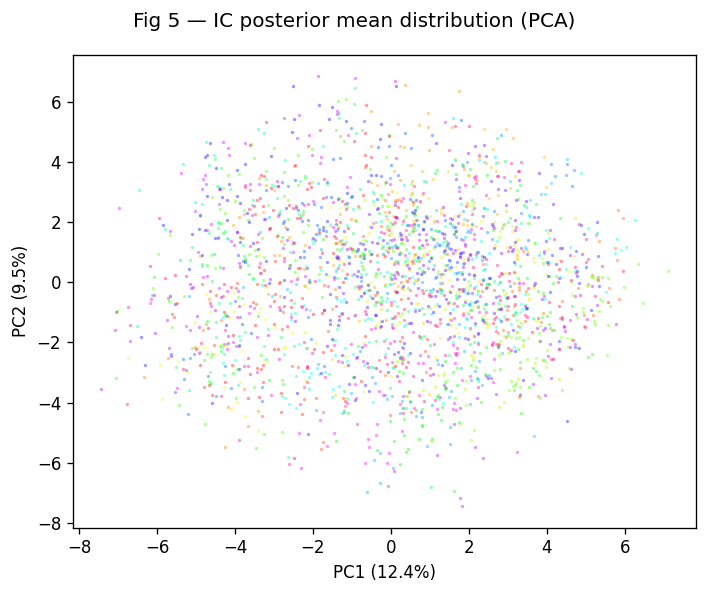

In [8]:
ic_tr  = d["train_ic_mean"].astype(float)
ic_va  = d["valid_ic_mean"].astype(float)
ic_all = np.concatenate([ic_tr, ic_va], axis=0)

labels_tr  = cond_labels(d["train_cond_idx"], len(ic_tr))
labels_va2 = cond_labels(d["valid_cond_idx"],  len(ic_va))
labels_all = np.concatenate([labels_tr, labels_va2])

ss2   = StandardScaler()
pca2  = PCA(n_components=2)
ic_2d = pca2.fit_transform(ss2.fit_transform(ic_all))
var2  = pca2.explained_variance_ratio_ * 100

unique_all = np.array([l for l in np.unique(labels_all) if l >= 0])
n_unique   = len(unique_all)

fig, ax = plt.subplots(figsize=(6, 5))
for c in unique_all:
    mask = labels_all == c
    ax.scatter(
        ic_2d[mask, 0], ic_2d[mask, 1],
        color=cm.hsv(c / n_unique), s=4, alpha=0.4, linewidths=0,
    )
ax.set_xlabel(f"PC1 ({var2[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var2[1]:.1f}%)")
fig.suptitle("Fig 5 — IC posterior mean distribution (PCA)", fontsize=12)
plt.tight_layout()

## Summary

In [ ]:
gain = r2_fac.mean() - r2_spk.mean()
print("══ Summary ══════════════════════════════════════════════════════════════")
print(f"  PSTH R²               : {psth_r2:.3f}  (1.0 = perfect condition-averaged fit)")
print(f"  Decoding R² (factors) : {r2_fac.mean():.3f}  (mean over x/y velocity)")
print(f"  Decoding R² (spikes)  : {r2_spk.mean():.3f}  (mean over x/y velocity)")
print(f"  LFADS gain            : {gain:+.3f}  "
      f"({'factors better' if gain > 0 else 'spikes better'})")
print("════════════════════════════════════════════════════════════════════════")